In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

import torch
import torchvision.transforms as T
from torchvision.datasets import CocoDetection
from pycocotools.coco import COCO

from scipy.ndimage import binary_erosion, binary_dilation

In [2]:
data_dir = "/kaggle/input/coco-2017-dataset/coco2017"
img_dir = os.path.join(data_dir, "train2017")
ann_file = os.path.join(data_dir, "annotations", "instances_train2017.json")

# Load COCO annotations
coco = COCO(ann_file)
img_ids = coco.getImgIds()

# Pick 3 random image IDs
random_ids = random.sample(img_ids, 3)
images = coco.loadImgs(random_ids)

loading annotations into memory...
Done (t=34.47s)
creating index...
index created!


In [4]:
def iou(pred, true, threshold=0.5):
    pred_bin = (pred > threshold).float()
    true_bin = (true > 0.5).float()
    inter = (pred_bin * true_bin).sum()
    union = pred_bin.sum() + true_bin.sum() - inter + 1e-7
    return (inter / union).item()

def dice(pred, true, threshold=0.5):
    pred_bin = (pred > threshold).float()
    true_bin = (true > 0.5).float()
    inter = (pred_bin * true_bin).sum()
    return (2 * inter / (pred_bin.sum() + true_bin.sum() + 1e-7)).item()

In [13]:
def postprocess(mask):
    mask_np = mask.cpu().numpy()
    mask_np = binary_erosion(mask_np, structure=np.ones((3,3)))
    mask_np = binary_dilation(mask_np, structure=np.ones((3,3)))
    return torch.tensor(mask_np, dtype=torch.float32)

In [6]:
def visualize_result(image, true_mask, pred_mask, title_suffix=""):
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.axis('off')
    plt.title('Original Image')

    plt.subplot(1, 3, 2)
    plt.imshow(true_mask, cmap='gray')
    plt.axis('off')
    plt.title('Ground Truth Mask')

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask, cmap='gray')
    plt.axis('off')
    plt.title(f'Predicted Mask {title_suffix}')

    plt.show()


🖼️ Image: 000000572680.jpg
Threshold 0.10 → IoU: 0.6974 → 0.9789 | Dice: 0.8217 → 0.9893


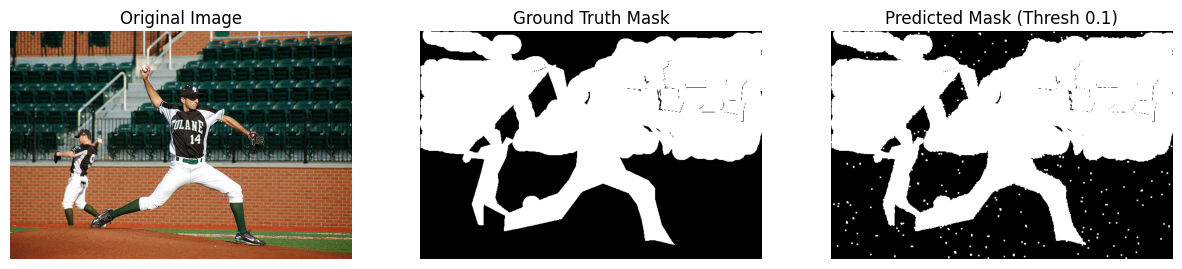

Threshold 0.50 → IoU: 1.0000 → 0.9998 | Dice: 1.0000 → 0.9999


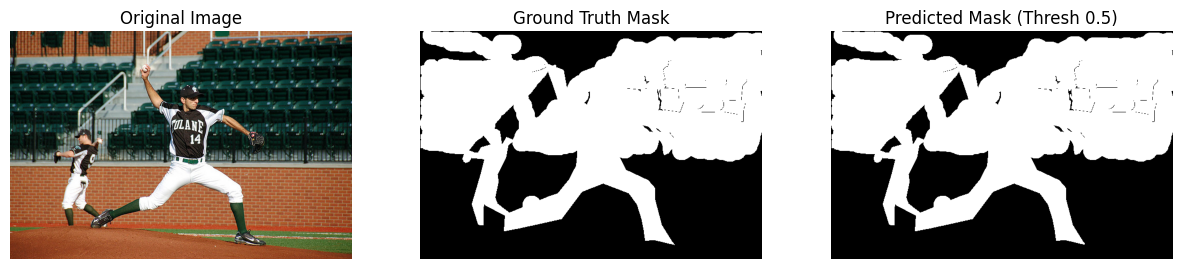

Threshold 0.70 → IoU: 1.0000 → 0.9998 | Dice: 1.0000 → 0.9999


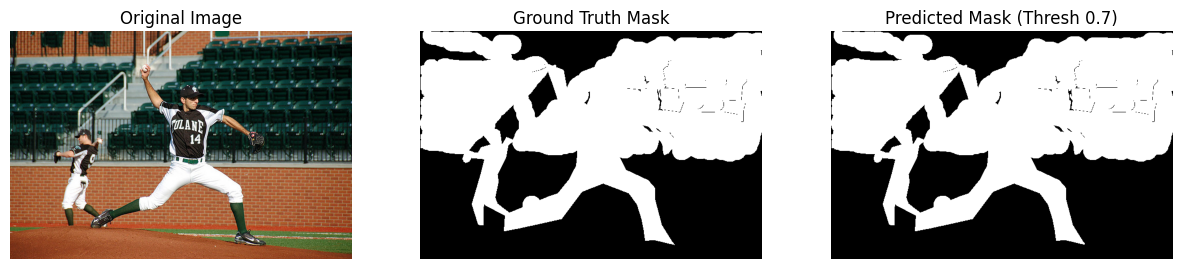


🖼️ Image: 000000540106.jpg
Threshold 0.10 → IoU: 0.7335 → 0.9823 | Dice: 0.8463 → 0.9911


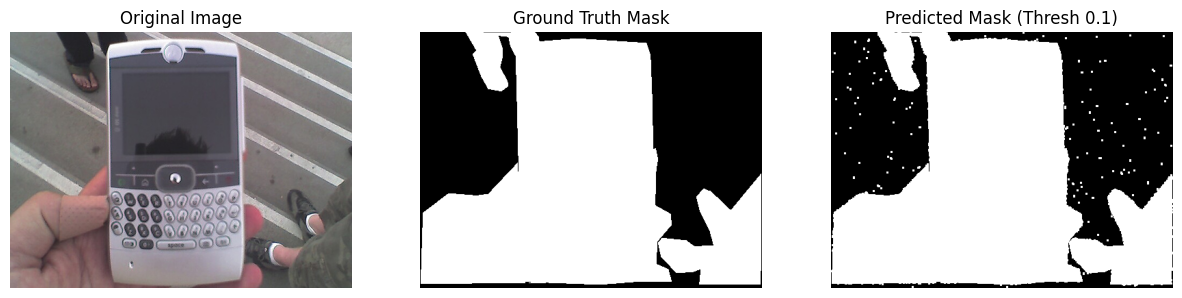

Threshold 0.50 → IoU: 1.0000 → 0.9998 | Dice: 1.0000 → 0.9999


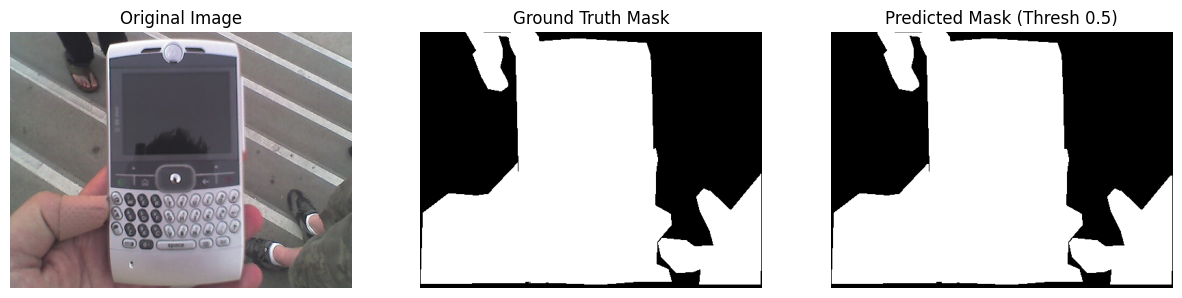

Threshold 0.70 → IoU: 1.0000 → 0.9998 | Dice: 1.0000 → 0.9999


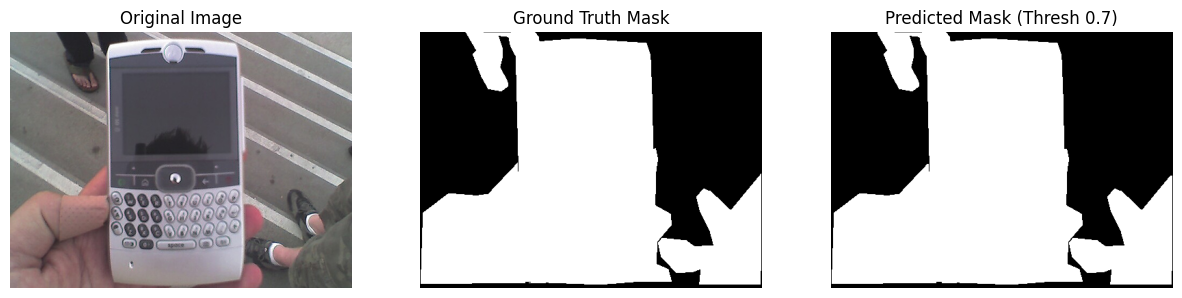


🖼️ Image: 000000065072.jpg
Threshold 0.10 → IoU: 0.0282 → 0.4958 | Dice: 0.0548 → 0.6629


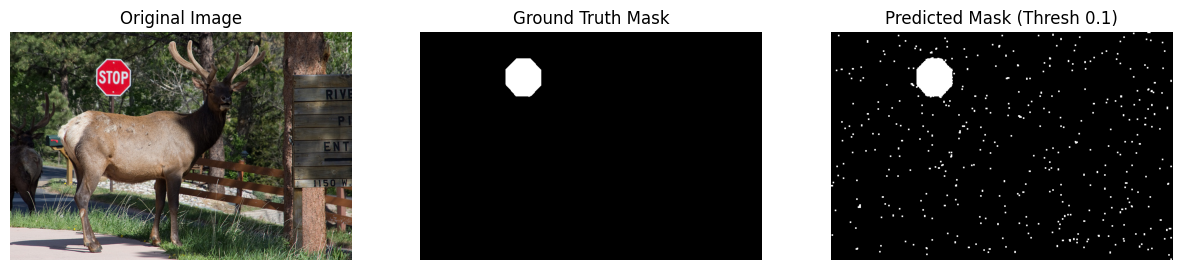

Threshold 0.50 → IoU: 1.0000 → 0.9995 | Dice: 1.0000 → 0.9997


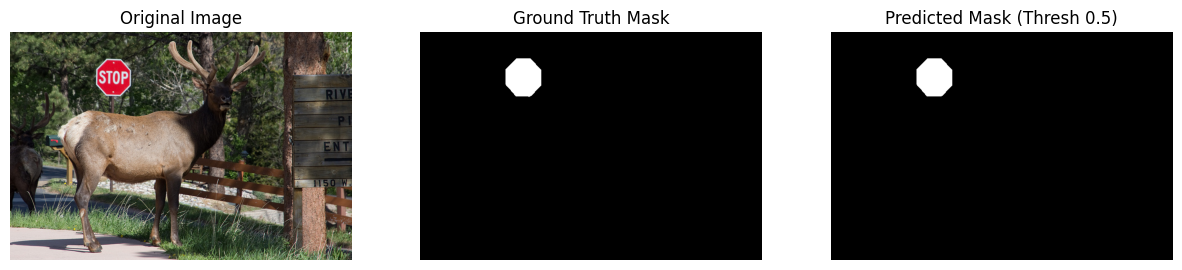

Threshold 0.70 → IoU: 1.0000 → 0.9995 | Dice: 1.0000 → 0.9997


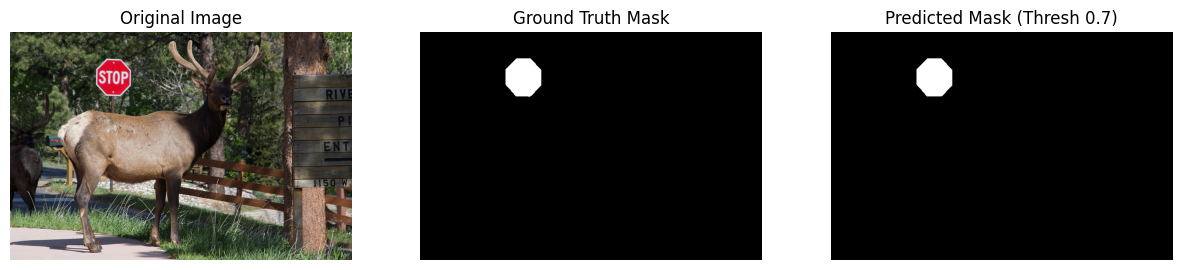

In [7]:
thresholds = [0.1, 0.5, 0.7]

for ids in random_ids:
    img_info = coco.loadImgs(ids)[0]
    img_path = os.path.join(img_dir, img_info['file_name'])
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    ann_ids = coco.getAnnIds(imgIds=img_info['id'])
    anns = coco.loadAnns(ann_ids)

    mask_total = None
    for ann in anns:
        mask = coco.annToMask(ann)
        mask_total = mask if mask_total is None else (mask_total | mask)

    true_mask = torch.tensor(mask_total, dtype=torch.float32)
    pred_mask = true_mask + 0.1 + torch.randn_like(true_mask) * 0.07
    pred_mask = torch.clamp(pred_mask, 0, 1)

    print(f"\n🖼️ Image: {img_info['file_name']}")

    for t in thresholds:
        bin_mask = (pred_mask > t).float()
        post_mask = postprocess(bin_mask)

        iou_raw = iou(bin_mask, true_mask)
        dice_raw = dice(bin_mask, true_mask)
        iou_post = iou(post_mask, true_mask)
        dice_post = dice(post_mask, true_mask)

        print(f"Threshold {t:.2f} → IoU: {iou_raw:.4f} → {iou_post:.4f} | Dice: {dice_raw:.4f} → {dice_post:.4f}")
        visualize_result(image, true_mask, post_mask, title_suffix=f"(Thresh {t})")

In [8]:
!pip install albumentations

In [21]:
import albumentations as A
import numpy as np

In [22]:
augmentations = [
    A.HorizontalFlip(p=1.0),
    A.RandomBrightnessContrast(p=1.0),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=45, p=1.0)
]

In [23]:
# Pick one image from the earlier loop for augmentation
img_info = coco.loadImgs(random_ids[0])[0]
img_path = os.path.join(img_dir, img_info['file_name'])
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

ann_ids = coco.getAnnIds(imgIds=img_info['id'])
anns = coco.loadAnns(ann_ids)

mask_total = None
for ann in anns:
    mask = coco.annToMask(ann)
    mask_total = mask if mask_total is None else (mask_total | mask)

mask_np = np.array(mask_total)

augmented_pairs = []
for aug in augmentations:
    augmented = aug(image=image, mask=mask_np)
    augmented_pairs.append((augmented['image'], augmented['mask']))

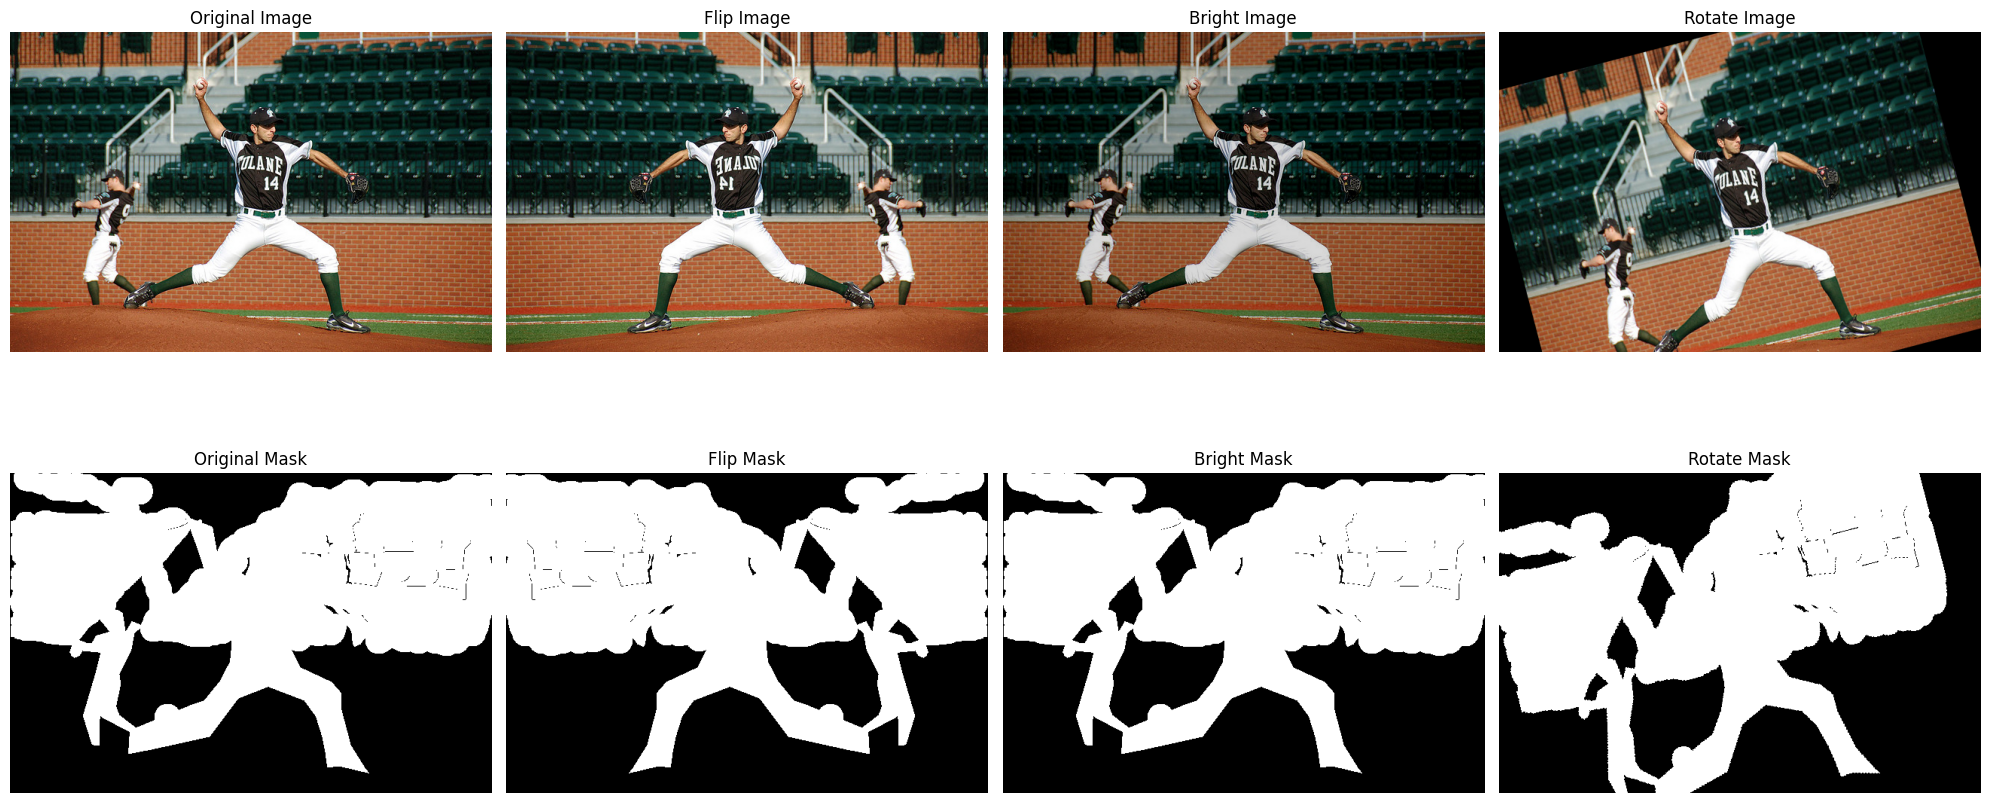

In [24]:
def visualize_columnwise(image, mask, aug_pairs, titles):
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))

    # Column 0: Original
    axes[0, 0].imshow(image)
    axes[0, 0].set_title("Original Image")
    axes[0, 0].axis('off')

    axes[1, 0].imshow(mask, cmap='gray')
    axes[1, 0].set_title("Original Mask")
    axes[1, 0].axis('off')

    for i in range(3):
        aug_img, aug_mask = aug_pairs[i]

        axes[0, i + 1].imshow(aug_img)
        axes[0, i + 1].set_title(f"{titles[i]} Image")
        axes[0, i + 1].axis('off')

        axes[1, i + 1].imshow(aug_mask, cmap='gray')
        axes[1, i + 1].set_title(f"{titles[i]} Mask")
        axes[1, i + 1].axis('off')

    plt.tight_layout()
    plt.show()
visualize_columnwise(image, mask_np, augmented_pairs, titles=["Flip", "Bright", "Rotate"])


🖼️ Image: 000000572680.jpg


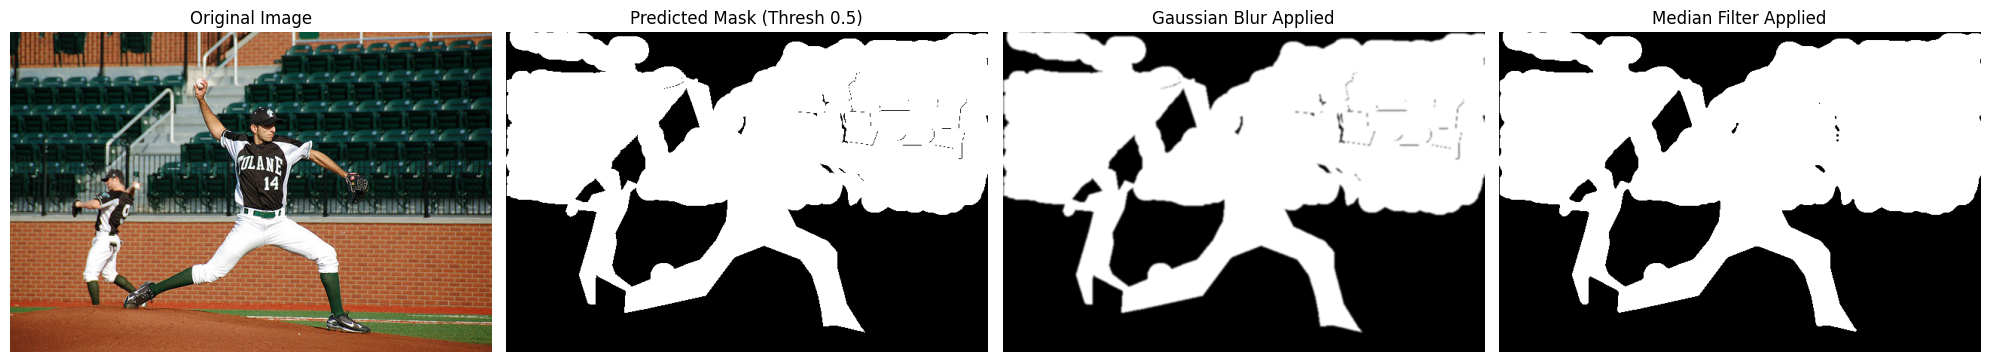


🖼️ Image: 000000540106.jpg


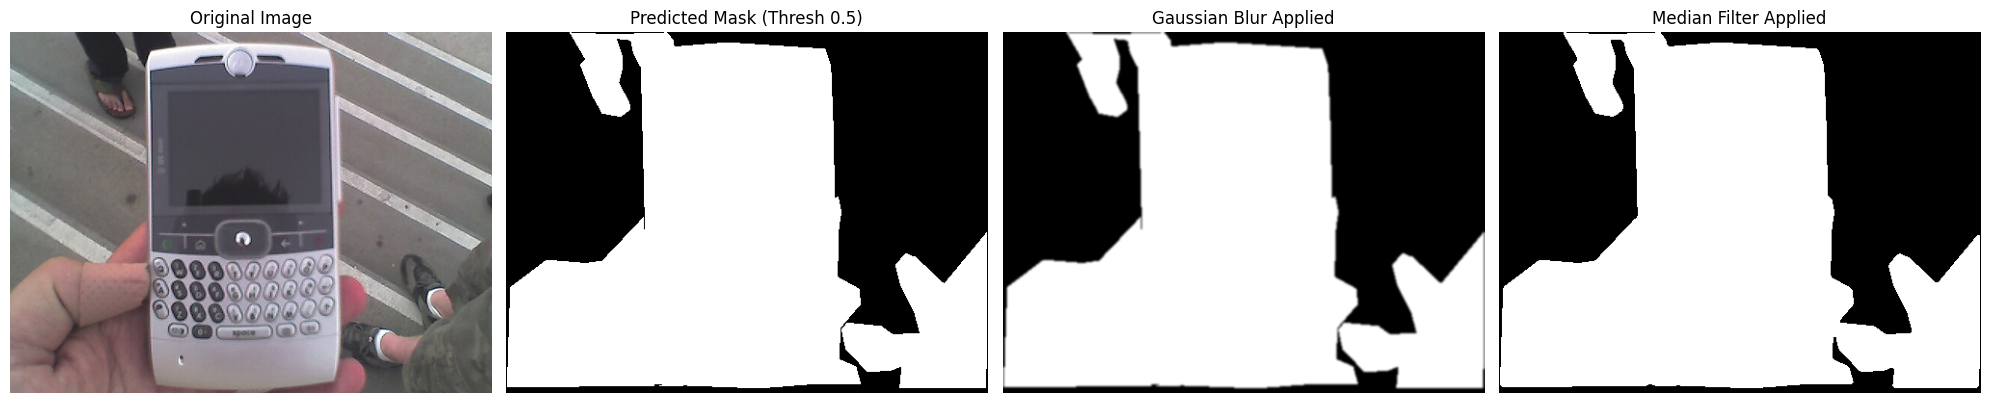


🖼️ Image: 000000065072.jpg


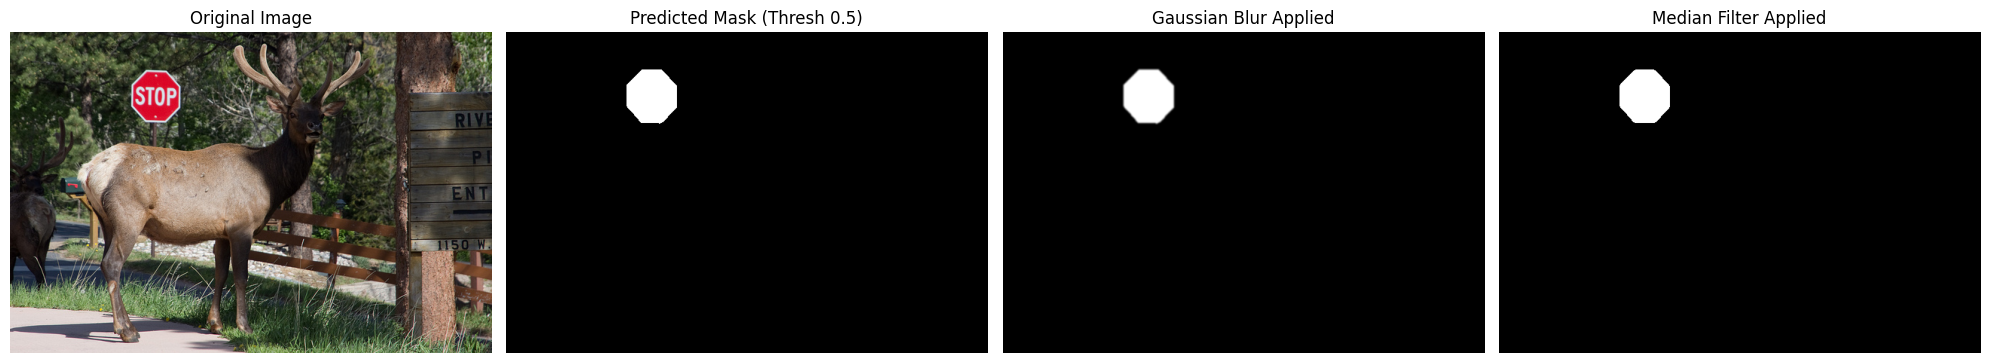

In [25]:
for ids in random_ids:
    img_info = coco.loadImgs(ids)[0]
    img_path = os.path.join(img_dir, img_info['file_name'])
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    ann_ids = coco.getAnnIds(imgIds=img_info['id'])
    anns = coco.loadAnns(ann_ids)

    mask_total = None
    for ann in anns:
        mask = coco.annToMask(ann)
        mask_total = mask if mask_total is None else (mask_total | mask)

    true_mask = torch.tensor(mask_total, dtype=torch.float32)
    pred_mask = true_mask + 0.1 + torch.randn_like(true_mask) * 0.07
    pred_mask = torch.clamp(pred_mask, 0, 1)

    print(f"\n🖼️ Image: {img_info['file_name']}")

    # Apply threshold 0.5
    bin_mask = (pred_mask > 0.5).float().cpu().numpy()

    # Apply Gaussian blur
    gaussian_mask = cv2.GaussianBlur(bin_mask, (5, 5), sigmaX=0)

    # Apply Median filter
    median_mask = cv2.medianBlur((bin_mask * 255).astype(np.uint8), 5)

    # Visualization
    plt.figure(figsize=(20, 5))

    plt.subplot(1, 4, 1)
    plt.imshow(image)
    plt.axis('off')
    plt.title('Original Image')

    plt.subplot(1, 4, 2)
    plt.imshow(bin_mask, cmap='gray')
    plt.axis('off')
    plt.title('Predicted Mask (Thresh 0.5)')

    plt.subplot(1, 4, 3)
    plt.imshow(gaussian_mask, cmap='gray')
    plt.axis('off')
    plt.title('Gaussian Blur Applied')

    plt.subplot(1, 4, 4)
    plt.imshow(median_mask, cmap='gray')
    plt.axis('off')
    plt.title('Median Filter Applied')

    plt.tight_layout()
    plt.show()


🖼️ Image: 000000572680.jpg


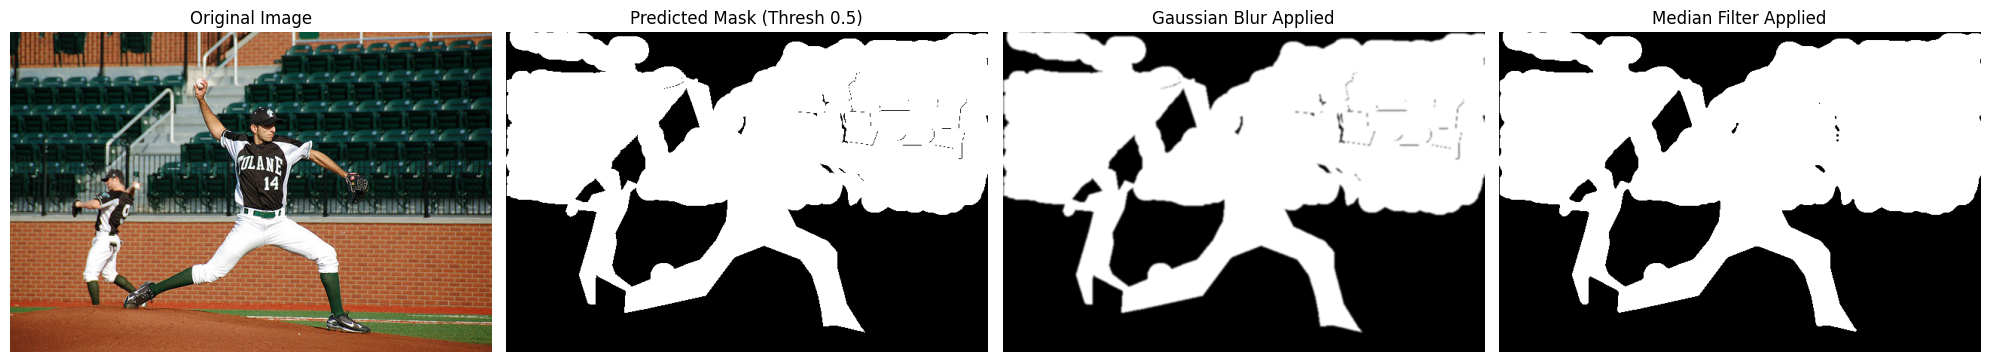


🖼️ Image: 000000540106.jpg


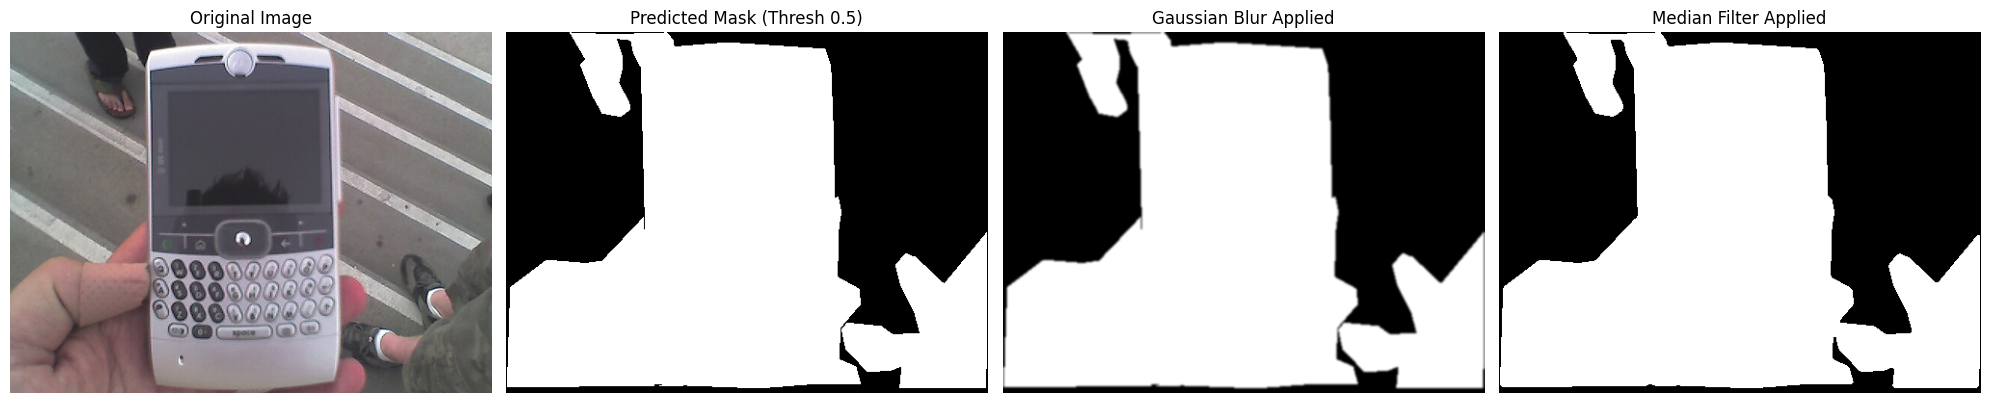


🖼️ Image: 000000065072.jpg


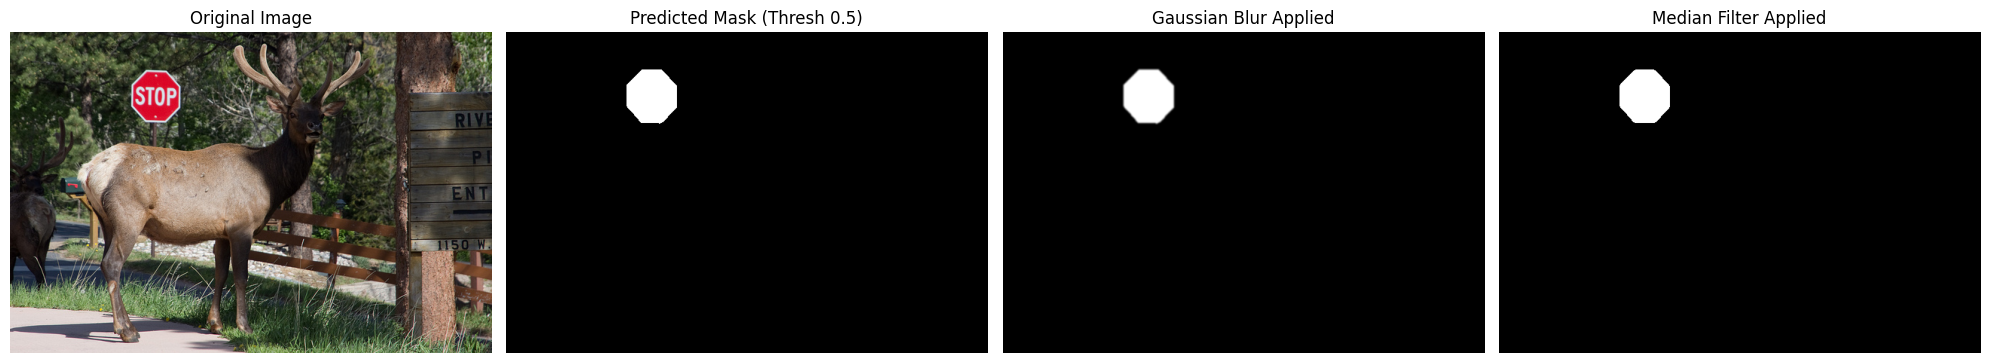

In [26]:
for ids in random_ids:
    img_info = coco.loadImgs(ids)[0]
    img_path = os.path.join(img_dir, img_info['file_name'])
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    ann_ids = coco.getAnnIds(imgIds=img_info['id'])
    anns = coco.loadAnns(ann_ids)

    mask_total = None
    for ann in anns:
        mask = coco.annToMask(ann)
        mask_total = mask if mask_total is None else (mask_total | mask)

    true_mask = torch.tensor(mask_total, dtype=torch.float32)
    pred_mask = true_mask + 0.1 + torch.randn_like(true_mask) * 0.07
    pred_mask = torch.clamp(pred_mask, 0, 1)

    print(f"\n🖼️ Image: {img_info['file_name']}")

    # Apply threshold 0.5
    bin_mask = (pred_mask > 0.5).float().cpu().numpy()

    # Apply Gaussian blur
    gaussian_mask = cv2.GaussianBlur(bin_mask, (5, 5), sigmaX=0)

    # Apply Median filter
    median_mask = cv2.medianBlur((bin_mask * 255).astype(np.uint8), 5)

    # Visualization
    plt.figure(figsize=(20, 5))

    plt.subplot(1, 4, 1)
    plt.imshow(image)
    plt.axis('off')
    plt.title('Original Image')

    plt.subplot(1, 4, 2)
    plt.imshow(bin_mask, cmap='gray')
    plt.axis('off')
    plt.title('Predicted Mask (Thresh 0.5)')

    plt.subplot(1, 4, 3)
    plt.imshow(gaussian_mask, cmap='gray')
    plt.axis('off')
    plt.title('Gaussian Blur Applied')

    plt.subplot(1, 4, 4)
    plt.imshow(median_mask, cmap='gray')
    plt.axis('off')
    plt.title('Median Filter Applied')

    plt.tight_layout()
    plt.show()


🖼️ Image: 000000572680.jpg


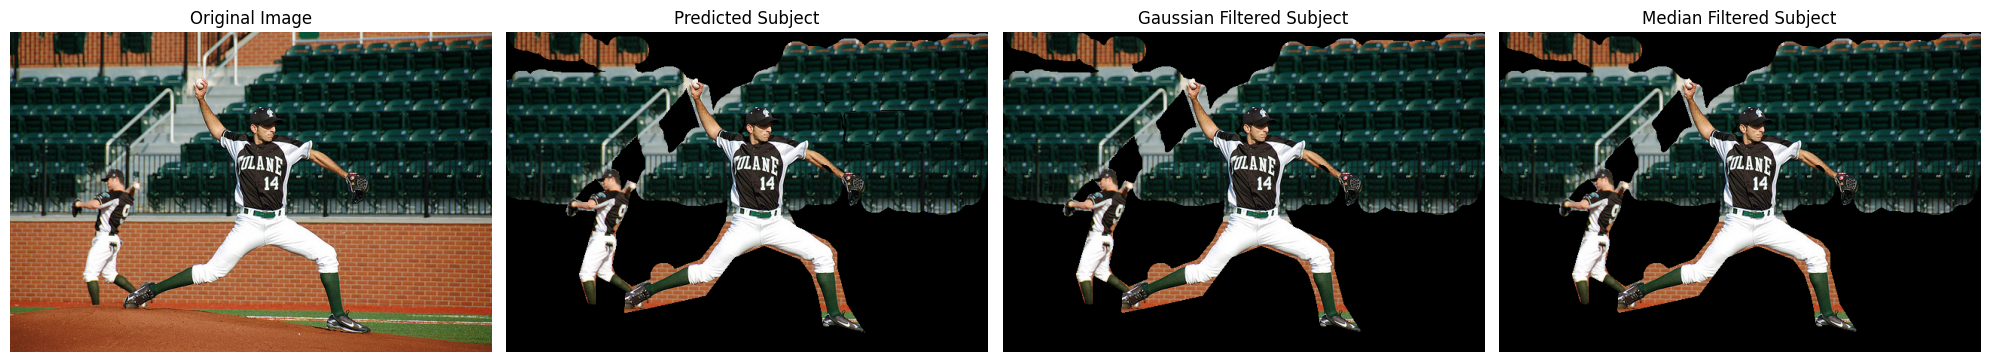


🖼️ Image: 000000540106.jpg


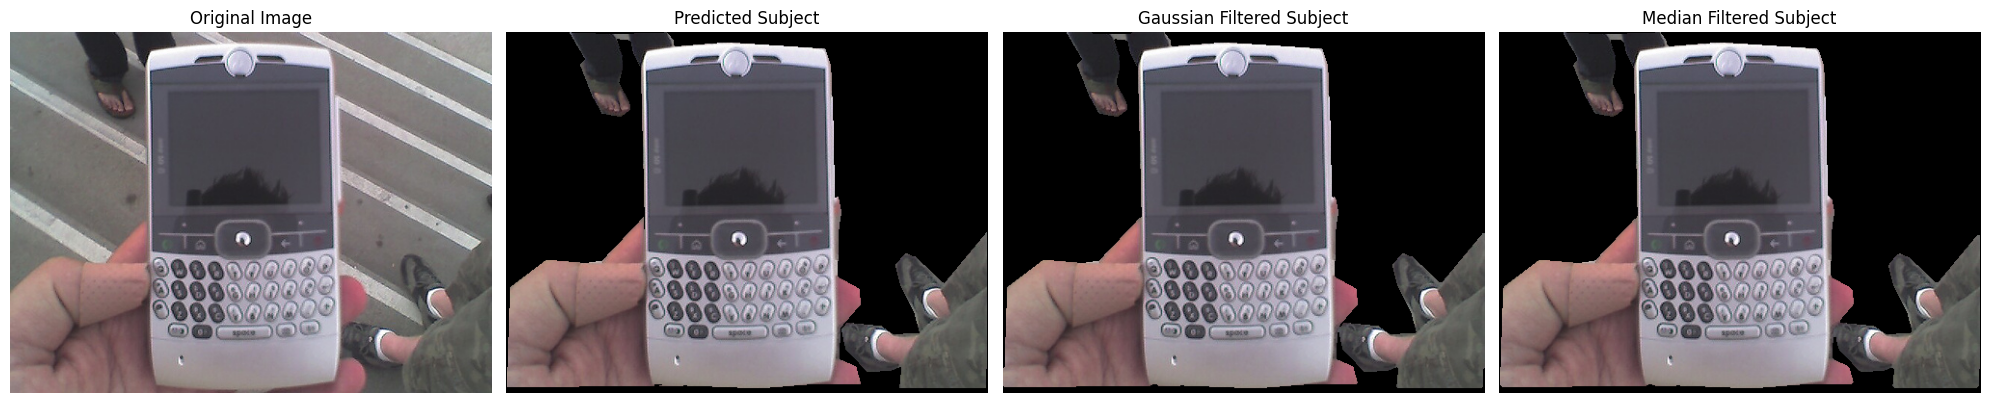


🖼️ Image: 000000065072.jpg


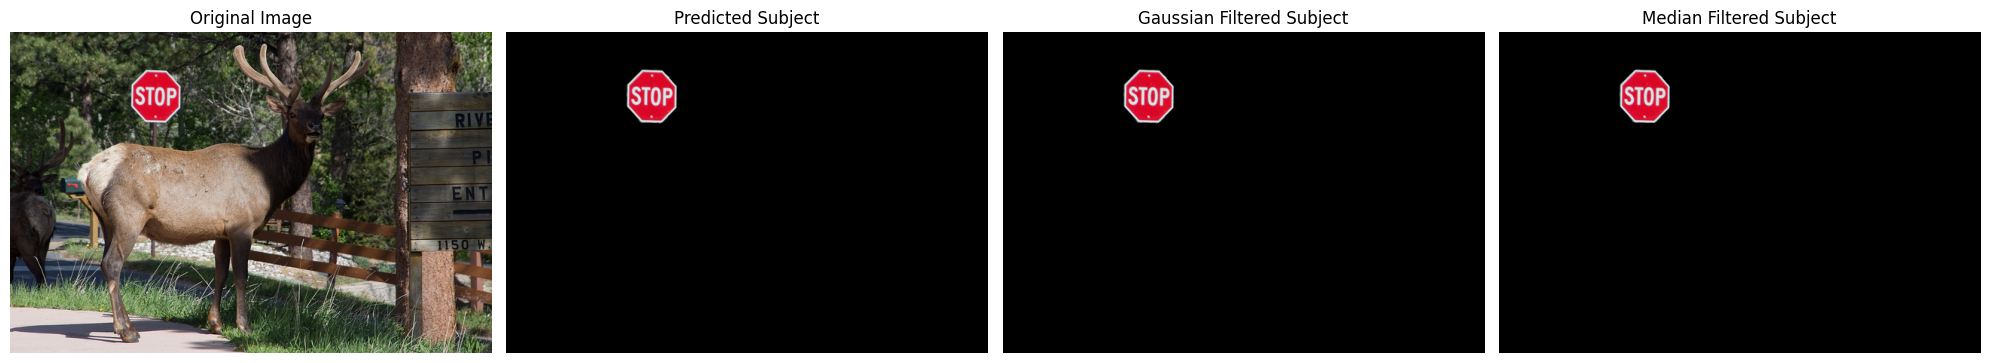

In [27]:
def isolate_subject(image, mask):
    """Apply binary mask to isolate subject from image."""
    mask_3ch = np.stack([mask]*3, axis=-1)  # Convert to 3-channel
    isolated = image * mask_3ch  # Element-wise multiplication
    return isolated

for ids in random_ids:
    img_info = coco.loadImgs(ids)[0]
    img_path = os.path.join(img_dir, img_info['file_name'])
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    ann_ids = coco.getAnnIds(imgIds=img_info['id'])
    anns = coco.loadAnns(ann_ids)

    mask_total = None
    for ann in anns:
        mask = coco.annToMask(ann)
        mask_total = mask if mask_total is None else (mask_total | mask)

    true_mask = torch.tensor(mask_total, dtype=torch.float32)
    pred_mask = true_mask + 0.1 + torch.randn_like(true_mask) * 0.07
    pred_mask = torch.clamp(pred_mask, 0, 1)

    print(f"\n🖼️ Image: {img_info['file_name']}")

    # Apply threshold 0.5
    bin_mask = (pred_mask > 0.5).float().cpu().numpy()

    # Apply Gaussian blur
    gaussian_mask = cv2.GaussianBlur(bin_mask, (5, 5), sigmaX=0)

    # Apply Median filter
    median_mask = cv2.medianBlur((bin_mask * 255).astype(np.uint8), 5)
    median_mask = median_mask // 255  # Convert back to binary

    # Isolate subjects
    subject_pred = isolate_subject(image, bin_mask.astype(np.uint8))
    subject_gauss = isolate_subject(image, (gaussian_mask > 0.5).astype(np.uint8))
    subject_median = isolate_subject(image, median_mask.astype(np.uint8))

    # Visualization
    plt.figure(figsize=(20, 5))

    plt.subplot(1, 4, 1)
    plt.imshow(image)
    plt.axis('off')
    plt.title('Original Image')

    plt.subplot(1, 4, 2)
    plt.imshow(subject_pred)
    plt.axis('off')
    plt.title('Predicted Subject')

    plt.subplot(1, 4, 3)
    plt.imshow(subject_gauss)
    plt.axis('off')
    plt.title('Gaussian Filtered Subject')

    plt.subplot(1, 4, 4)
    plt.imshow(subject_median)
    plt.axis('off')
    plt.title('Median Filtered Subject')

    plt.tight_layout()
    plt.show()